In [2529]:
import pandas as pd

In [2530]:
import numpy as np

In [2531]:
df = pd.read_csv(r"C:\Users\bhard\Desktop\GRIDATHON\Astram event data_anonymized - Astram event data_anonymizedb40ac87 (2).csv")

In [2532]:
df.shape

(8173, 46)

In [2533]:
df.head()

,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [2534]:
df.isna().sum()

id                          0
event_type                  0
latitude                    0
longitude                   0
endlatitude               169
endlongitude              169
address                     3
end_address              7486
event_cause                 0
requires_road_closure       0
start_datetime              0
end_datetime             7683
status                      0
authenticated               0
modified_datetime           0
map_file                 8173
direction                8130
description              1360
veh_type                 3286
veh_no                   3287
corridor                   20
priority                    2
cargo_material           7897
reason_breakdown         7897
age_of_truck             7897
created_date                0
route_path               8036
client_id                   0
created_by_id               2
last_modified_by_id         3
assigned_to_police_id    8045
citizen_accident_id      8045
comment                  8173
police_sta

calculating percentage of  missing data so that we could identify 

In [2535]:
missing_percentage=(df.isna().sum()/df.shape[0])*100
missing_percentage

id                         0.000000
event_type                 0.000000
latitude                   0.000000
longitude                  0.000000
endlatitude                2.067784
endlongitude               2.067784
address                    0.036706
end_address               91.594274
event_cause                0.000000
requires_road_closure      0.000000
start_datetime             0.000000
end_datetime              94.004649
status                     0.000000
authenticated              0.000000
modified_datetime          0.000000
map_file                 100.000000
direction                 99.473877
description               16.640157
veh_type                  40.205555
veh_no                    40.217790
corridor                   0.244708
priority                   0.024471
cargo_material            96.623027
reason_breakdown          96.623027
age_of_truck              96.623027
created_date               0.000000
route_path                98.323749
client_id                  0

In [2536]:
missing_percentage.sort_values(ascending=False)

comment                  100.000000
map_file                 100.000000
meta_data                100.000000
direction                 99.473877
resolved_at_address       99.094580
resolved_at_latitude      99.094580
resolved_by_id            99.094580
resolved_datetime         99.094580
resolved_at_longitude     99.094580
assigned_to_police_id     98.433868
citizen_accident_id       98.433868
route_path                98.323749
age_of_truck              96.623027
reason_breakdown          96.623027
cargo_material            96.623027
end_datetime              94.004649
end_address               91.594274
junction                  69.289123
closed_datetime           61.568579
closed_by_id              61.568579
gba_identifier            57.861250
zone                      57.861250
veh_no                    40.217790
veh_type                  40.205555
description               16.640157
kgid                       3.168971
endlongitude               2.067784
endlatitude                2

In [2537]:
df["start_datetime"].isna().sum()

np.int64(0)

In [2538]:
df["end_datetime"].isna().sum()

np.int64(7683)

In [2539]:
df[df["end_datetime"].notna()].shape

(490, 46)

In [2540]:
df["status"].value_counts()

status
closed      7095
active      1007
resolved      71
Name: count, dtype: int64

In [2541]:
df["status"].isna().sum()

np.int64(0)

In [2542]:
df[df["status"] == "closed"]["end_datetime"].isna().sum()

np.int64(6618)

In [2543]:
df[df["status"] == "closed"]["end_datetime"].notna().sum()

np.int64(477)

In [2544]:
droppinf_columns_1=["client_id","created_by_id","resolved_by_id","id"]

In [2545]:
df.drop(columns=droppinf_columns_1,inplace=True)

In [2546]:
df.shape

(8173, 42)

we will possibly look for the structure of the columns that will help us find the strucyture of the data 

In [2547]:
#our columns are status end_datetime and resolved_datetime and closed_date time so we need to inspect the missing  data in these columns 

In [2548]:
df["status"].isna().sum()


np.int64(0)

In [2549]:
df["end_datetime"].isna().sum()

np.int64(7683)

In [2550]:
df["resolved_datetime"].isna().sum()

np.int64(8099)

In [2551]:
df["closed_datetime"].isna().sum()

np.int64(5032)

In [2552]:
df[[
    "end_datetime",
    "resolved_datetime",
    "closed_datetime"
]].notna().sum()

end_datetime          490
resolved_datetime      74
closed_datetime      3141
dtype: int64

In [2553]:
timestamp_count = (
    df[[
        "end_datetime",
        "resolved_datetime",
        "closed_datetime"
    ]]
    .notna()
    .sum(axis=1)
)

timestamp_count.value_counts().sort_index()

0    4509
1    3623
2      41
Name: count, dtype: int64

In [2554]:
df[df["closed_datetime"].notna()]["status"].value_counts()

status
closed      3139
resolved       2
Name: count, dtype: int64

In [2555]:
df["start_datetime"] = pd.to_datetime(
    df["start_datetime"],
    errors="coerce"
)

df["closed_datetime"] = pd.to_datetime(
    df["closed_datetime"],
    errors="coerce"
)

df["resolved_datetime"] = pd.to_datetime(
    df["resolved_datetime"],
    errors="coerce"
)

df["end_datetime"] = pd.to_datetime(
    df["end_datetime"],
    errors="coerce"
)

In [2556]:
df[[
    "start_datetime",
    "closed_datetime",
    "resolved_datetime",
    "end_datetime"
]].dtypes

start_datetime       datetime64[ns, UTC]
closed_datetime      datetime64[ns, UTC]
resolved_datetime    datetime64[ns, UTC]
end_datetime         datetime64[ns, UTC]
dtype: object

In [2557]:
df["completion_datetime"] = (
    df["closed_datetime"]
        .fillna(df["resolved_datetime"])
        .fillna(df["end_datetime"])
)

In [2558]:
print("Completion present :", df["completion_datetime"].notna().sum())
print("Completion missing :", df["completion_datetime"].isna().sum())

Completion present : 3650
Completion missing : 4523


In [2559]:
df["completion_datetime"].isna().sum()

np.int64(4523)

In [2560]:
df_completed=df[df["completion_datetime"].notna()].copy()

In [2561]:
df_completed.shape

(3650, 43)

In [2562]:
df_completed["duration_minutes"] = (
    df_completed["completion_datetime"] -
    df_completed["start_datetime"]
).dt.total_seconds() / 60

In [2563]:
df_completed.shape

(3650, 44)

In [2564]:
df_completed["duration_minutes"].describe()

count    3.548000e+03
mean     6.530730e+03
std      4.023427e+04
min     -1.360162e+03
25%      2.710932e+01
50%      6.759725e+01
75%      7.190165e+02
max      2.051059e+06
Name: duration_minutes, dtype: float64

In [2565]:
df_completed["event_cause"].unique()

array(['vehicle_breakdown', 'others', 'tree_fall', 'public_event',
       'water_logging', 'pot_holes', 'construction', 'road_conditions',
       'vip_movement', 'accident', 'procession', 'congestion', 'protest',
       'test_demo', 'Debris'], dtype=object)

In [2566]:
df_completed["event_cause"] = (
    df_completed["event_cause"]
    .str.strip()
    .str.lower()
)

In [2567]:
sorted(df_completed["event_cause"].unique())

['accident',
 'congestion',
 'construction',
 'debris',
 'others',
 'pot_holes',
 'procession',
 'protest',
 'public_event',
 'road_conditions',
 'test_demo',
 'tree_fall',
 'vehicle_breakdown',
 'vip_movement',
 'water_logging']

In [2568]:
df_completed.groupby("event_cause")["duration_minutes"] \
    .agg(
        count="count",
        median_duration="median",
        mean_duration="mean"
    ) \
    .sort_values("median_duration", ascending=False)

,count,median_duration,mean_duration
event_cause,,,
debris,4,86853.319002,97302.646787
pot_holes,177,12671.138812,34786.363658
vip_movement,4,8683.826758,10032.973996
road_conditions,93,8448.448308,25609.204368
water_logging,245,3688.330755,14134.737913
construction,373,720.764967,11015.794890
tree_fall,176,631.478332,6033.798951
others,421,406.328939,12334.121113
public_event,44,163.200275,2180.360858


In [2569]:
df_completed.columns

Index(['event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude',
       'address', 'end_address', 'event_cause', 'requires_road_closure',
       'start_datetime', 'end_datetime', 'status', 'authenticated',
       'modified_datetime', 'map_file', 'direction', 'description', 'veh_type',
       'veh_no', 'corridor', 'priority', 'cargo_material', 'reason_breakdown',
       'age_of_truck', 'created_date', 'route_path', 'last_modified_by_id',
       'assigned_to_police_id', 'citizen_accident_id', 'comment',
       'police_station', 'meta_data', 'kgid', 'resolved_at_address',
       'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id',
       'closed_datetime', 'resolved_datetime', 'gba_identifier', 'zone',
       'junction', 'completion_datetime', 'duration_minutes'],
      dtype='object')

Group 1: Gold Features (almost certainly useful)

These are available when the event is reported.

event_type
event_cause
latitude
longitude
corridor
zone
junction
direction
priority
police_station
requires_road_closure
authenticated

These are your strongest candidates.

In [2570]:
import seaborn as sns  

<Axes: xlabel='duration_minutes', ylabel='event_cause'>

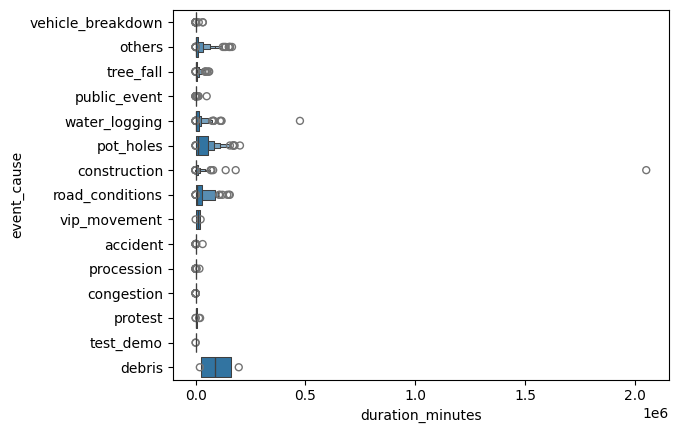

In [2571]:
sns.boxenplot(data=df_completed, x="duration_minutes", y="event_cause")

In [2572]:
df_completed["duration_minutes"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
]
)

0.500        67.597248
0.750       719.016525
0.900     14917.677606
0.950     35917.179417
0.990    105297.739538
0.995    147954.568271
0.999    188689.618114
Name: duration_minutes, dtype: float64

In [2573]:
df_completed["event_cause"].value_counts(normalize=True) * 100

event_cause
vehicle_breakdown    50.767123
others               11.589041
construction         11.287671
water_logging         6.712329
pot_holes             4.849315
tree_fall             4.821918
accident              2.575342
road_conditions       2.547945
public_event          2.219178
procession            1.260274
congestion            0.602740
vip_movement          0.356164
protest               0.246575
debris                0.109589
test_demo             0.054795
Name: proportion, dtype: float64

In [2574]:
rare_causes = (
    df_completed["event_cause"]
    .value_counts(normalize=True)
)

rare_causes = rare_causes[rare_causes < 0.01].index

df_completed["event_cause_grouped"] = (
    df_completed["event_cause"]
    .replace(rare_causes, "rare_event")
)

In [2575]:
df_completed["event_cause_grouped"].value_counts(normalize=True) * 100

event_cause_grouped
vehicle_breakdown    50.767123
others               11.589041
construction         11.287671
water_logging         6.712329
pot_holes             4.849315
tree_fall             4.821918
accident              2.575342
road_conditions       2.547945
public_event          2.219178
rare_event            1.369863
procession            1.260274
Name: proportion, dtype: float64

In [2576]:
df_completed.groupby("event_cause_grouped")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
event_cause_grouped,,,,
accident,94.0,27.197036,41.704889,65.238408
construction,373.0,51.122411,720.764967,2871.762243
others,421.0,59.494905,406.328939,10373.064849
pot_holes,177.0,1924.834030,12671.138812,57947.359122
procession,40.0,2.374034,38.854987,120.254194
public_event,44.0,3.170254,163.200275,411.192017
rare_event,40.0,16.865585,71.535313,155.347177
road_conditions,93.0,737.901199,8448.448308,28715.227126
tree_fall,176.0,66.885090,631.478332,5293.987003


event_type
event_cause
latitude
longitude
corridor
zone
junction
direction
priority
police_station
requires_road_closure
authenticated

In [2577]:
df_completed["event_type"].isna().sum()

np.int64(0)

In [2578]:
df_completed.groupby("event_type")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
event_type,,,,
planned,364.0,2.269540,255.116433,764.779392
unplanned,3184.0,28.078398,64.526588,364.757552


In [2579]:
df_completed["priority"].isna().sum()

np.int64(2)

In [2580]:
df_completed.groupby("priority")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
priority,,,,
High,2186.0,25.597770,64.164932,362.417806
Low,1362.0,30.007165,75.691808,1449.279921


In [2581]:
df_completed["requires_road_closure"].isna().sum()

np.int64(0)

In [2582]:
df_completed.groupby("requires_road_closure")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
requires_road_closure,,,,
False,3195.0,27.21683,65.950498,623.705488
True,353.0,24.44389,91.562741,2292.299490


In [2583]:
df_completed["police_station"].isna().sum()

np.int64(0)

In [2584]:
df_completed["police_station"].nunique()

54

In [2585]:
df_completed.groupby("police_station")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
police_station,,,,
Adugodi,45.0,40.030745,71.352264,12671.138812
Ashok Nagar,84.0,52.931379,99.342788,5416.918130
Banashankari,59.0,36.247948,57.316075,99.189130
Banaswadi,69.0,20.117849,43.703668,102.315176
Basavanagudi,22.0,47.609457,100.880800,769.198627
Bellandur,50.0,27.599458,71.981916,2557.329314
Byatarayanapura,138.0,23.941845,51.526817,110.551008
Chamarajpet,121.0,30.476748,71.049059,3082.978522
Chikkabanavara,10.0,24.491843,30.821325,65.958678


In [2586]:
df_completed.drop(columns=["police_station"], inplace=True)

In [2587]:
df_completed.shape

(3650, 44)

In [2588]:
df_completed["assigned_to_police_id"].isna().sum()

np.int64(3629)

In [2589]:
df_completed.drop(columns=["assigned_to_police_id"], inplace=True)

In [2590]:
df_completed.shape

(3650, 43)

In [2591]:
df_completed["corridor"].isna().sum()

np.int64(11)

In [2592]:
df_completed["corridor"].nunique()

22

In [2593]:
df_completed.groupby("corridor")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
corridor,,,,
Airport New South Road,36.0,21.706138,113.394016,1440.501867
Bannerghata Road,60.0,28.249783,75.504186,8560.714600
Bellary Road 1,242.0,23.868133,60.964661,151.871964
Bellary Road 2,155.0,29.191688,61.873341,162.801167
CBD 1,11.0,44.869288,64.514993,24578.588872
CBD 2,47.0,52.980076,97.369552,19117.920477
Hennur Main Road,37.0,70.369317,124.488463,6290.720822
Hosur Road,119.0,32.237730,71.500566,142.551975
IRR(Thanisandra road),22.0,26.408022,64.642880,6483.097767


In [2594]:
df_completed["junction"].isna().sum()   

np.int64(2470)

In [2595]:
df_completed["junction"].nunique()

259

In [2596]:
df_completed.groupby("junction")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
junction,,,,
17th Mn 1st Crs Aishwarya Stores Jn,1.0,55.782217,55.782217,55.782217
27th Cross Jayanagar(Ganapathi Temple),1.0,119.253865,119.253865,119.253865
28thMainJayanagarJunc,2.0,111211.750897,133311.099356,155410.447816
29thMainRdBTM LayoutJunc,2.0,35896.120285,35896.269068,35896.417850
5thMainHSR,2.0,7712.455336,15423.860122,23135.264908
...,...,...,...,...
YelhankaBypass,8.0,39.117748,67.374820,75.763498
YelhankaCircle,22.0,20.695411,47.145628,107.145053
Yemalur cross junc,3.0,151.939266,218.976657,2281.974251


In [2597]:
df_completed.drop(columns=["junction"], inplace=True)

In [2598]:
df_completed.shape

(3650, 42)

In [2599]:
df_completed["latitude"].isna().sum()

np.int64(0)

In [2600]:
df_completed["longitude"].isna().sum()

np.int64(0)

In [2601]:
df_completed["latitude"].nunique()

3623

In [2602]:
df_completed["longitude"].nunique()

3619

we will not drop them because they will help us understand that the latidudee and longitude can help us in k means clustering of data 


1. zone
2. authenticated
3. veh_type
4. hour
5. day_of_week
6. month

In [2603]:
df_completed["veh_type"].isna().sum()

np.int64(1802)

In [2604]:
df_completed["veh_type"].nunique()

10

In [2605]:
df_completed.groupby("veh_type")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
veh_type,,,,
auto,17.0,22.181698,27.943233,53.130251
bmtc_bus,668.0,22.220565,49.409364,78.734493
heavy_vehicle,302.0,21.939673,42.743273,79.799076
ksrtc_bus,71.0,16.114372,32.330133,60.561715
lcv,234.0,19.942064,35.052892,67.043456
others,174.0,19.001925,35.482980,67.855081
private_bus,119.0,22.607051,42.985210,78.057177
private_car,154.0,15.798851,29.319576,51.323572
taxi,33.0,18.113244,33.802993,86.541741


In [2606]:
df_completed.drop(columns=["veh_type"], inplace=True)

In [2607]:
df_completed.groupby("authenticated")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
authenticated,,,,
no,758.0,10.521928,27.265357,57.140331
yes,2790.0,36.646929,86.599693,1463.558445


In [2608]:
df["authenticated"].value_counts()

authenticated
yes    7166
no     1007
Name: count, dtype: int64

In [2609]:
df[["event_cause","authenticated","status"]].head(30)

,event_cause,authenticated,status
0,vehicle_breakdown,yes,closed
1,vehicle_breakdown,yes,resolved
2,others,yes,closed
3,tree_fall,yes,closed
4,vehicle_breakdown,yes,closed
5,accident,yes,closed
6,vehicle_breakdown,yes,closed
7,others,yes,closed
8,public_event,yes,closed
9,vehicle_breakdown,yes,closed


In [2610]:
df_completed.drop(columns=["authenticated"], inplace=True)

In [2611]:
df_completed.shape

(3650, 40)

In [2612]:
df_completed["zone"].isna().sum()

np.int64(2032)

In [2613]:
df_completed["zone"].nunique()

10

In [2614]:
df_completed.groupby("zone")["duration_minutes"] \
            .describe()[["count","25%","50%","75%"]]

,count,25%,50%,75%
zone,,,,
Central Zone 1,118.0,21.164950,53.036290,136.705280
Central Zone 2,287.0,23.167117,53.037633,110.771197
East Zone 1,141.0,39.862702,216.126667,726.549800
East Zone 2,100.0,31.582222,86.201420,1441.586319
North Zone 1,151.0,25.596231,91.127313,1440.926833
North Zone 2,170.0,19.796239,61.112190,210.847481
South Zone 1,69.0,48.055170,114.129290,11561.310606
South Zone 2,111.0,33.477433,86.804083,7834.408334
West Zone 1,220.0,30.125347,56.914673,116.264493


In [2615]:
df_completed["zone"] = df_completed["zone"].fillna("Unknown")

In [2616]:
df_completed.columns

Index(['event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude',
       'address', 'end_address', 'event_cause', 'requires_road_closure',
       'start_datetime', 'end_datetime', 'status', 'modified_datetime',
       'map_file', 'direction', 'description', 'veh_no', 'corridor',
       'priority', 'cargo_material', 'reason_breakdown', 'age_of_truck',
       'created_date', 'route_path', 'last_modified_by_id',
       'citizen_accident_id', 'comment', 'meta_data', 'kgid',
       'resolved_at_address', 'resolved_at_latitude', 'resolved_at_longitude',
       'closed_by_id', 'closed_datetime', 'resolved_datetime',
       'gba_identifier', 'zone', 'completion_datetime', 'duration_minutes',
       'event_cause_grouped'],
      dtype='object')

In [2617]:
df_completed["hour"] = df_completed["start_datetime"].dt.hour
df_completed["day_of_week"] = df_completed["start_datetime"].dt.dayofweek
df_completed["month"] = df_completed["start_datetime"].dt.month

In [2618]:
df_completed.groupby("hour")["duration_minutes"]\
            .describe()[["count","50%","75%","25%"]]

,count,50%,75%,25%
hour,,,,
0.0,186.0,44.140909,127.476993,20.636429
1.0,168.0,47.084080,115.063086,21.894803
2.0,177.0,60.465771,161.712423,21.594105
3.0,171.0,55.782217,103.505122,22.228061
4.0,251.0,52.991313,123.879663,25.264770
5.0,309.0,70.004205,259.419367,29.571942
6.0,299.0,79.297449,1438.550891,36.584252
7.0,222.0,81.361426,1468.903287,31.176094
8.0,143.0,50.017506,1024.482695,22.986847


In [2619]:
df_completed.groupby("day_of_week")["duration_minutes"] \
            .describe()[["count","50%"]]

,count,50%
day_of_week,,
0.0,398.0,64.811060
1.0,554.0,66.725069
2.0,509.0,64.498340
3.0,614.0,76.051917
4.0,556.0,73.553909
5.0,501.0,75.090859
6.0,416.0,50.280869


In [2620]:
df_completed.groupby("month")["duration_minutes"] \
            .describe()[["count","50%"]]

,count,50%
month,,
1.0,643.0,58.343839
2.0,582.0,59.995444
3.0,848.0,79.295154
4.0,244.0,75.122981
11.0,467.0,70.372042
12.0,764.0,70.543103


In [2621]:
df_completed[df_completed["duration_minutes"].isna()].head()

,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,start_datetime,...,closed_datetime,resolved_datetime,gba_identifier,zone,completion_datetime,duration_minutes,event_cause_grouped,hour,day_of_week,month
8,planned,12.978836,77.599537,NaN,NaN,"ಲಿಂಕ್ ರಸ್ತೆ, ಅಶೋಕನಗರ, ಬೆಂಗಳೂರು ಮಧ್ಯ ನಗರ ನಿಗಮ, ...",NaN,public_event,False,NaT,...,NaT,NaT,NaN,Unknown,2024-02-12 14:05:46+00:00,NaN,public_event,NaN,NaN,NaN
433,planned,12.907316,77.695582,12.911022,77.697975,"Gear School road, ದೊಡ್ಡಕನ್ನಲ್ಲಿ, ಗುಂಜೂರು, ಬೆಂಗ...","ದೊಡ್ಡಕನ್ನಲ್ಲಿ, ಗುಂಜೂರು, ಬೆಂಗಳೂರು ಪೂರ್ವ ನಗರ ನಿಗ...",public_event,True,NaT,...,NaT,NaT,NaN,Unknown,2024-02-04 09:05:46+00:00,NaN,public_event,NaN,NaN,NaN
439,planned,12.978782,77.599763,NaN,NaN,"ಕ್ವಿನ್ಸ್ ರಸ್ತೆ, ಶಾಂತಲಾ ನಗರ, ಅಶೋಕನಗರ, ಬೆಂಗಳೂರು ...",NaN,public_event,False,NaT,...,NaT,NaT,NaN,Unknown,2024-02-04 14:05:46+00:00,NaN,public_event,NaN,NaN,NaN
502,planned,12.926093,77.676237,12.930354,77.678453,"ಬೆಳ್ಳಂದೂರು, ಬೆಂಗಳೂರು ಪೂರ್ವ ನಗರ ನಿಗಮ, Bengaluru...","ಬೆಳ್ಳಂದೂರು, ಬೆಂಗಳೂರು ಪೂರ್ವ ನಗರ ನಿಗಮ, Bengaluru...",public_event,True,NaT,...,NaT,NaT,NaN,Unknown,2024-02-05 18:05:46+00:00,NaN,public_event,NaN,NaN,NaN
575,planned,12.969172,77.700547,0.000000,0.000000,"West Parallel Road, Karthik Nagar, Marathahall...",NaN,construction,False,NaT,...,NaT,NaT,NaN,Unknown,2024-02-06 09:05:46+00:00,NaN,construction,NaN,NaN,NaN


In [2622]:
df_completed[
    df_completed["duration_minutes"].isna()
][[
    "start_datetime",
    "completion_datetime"
]]

,start_datetime,completion_datetime
8,NaT,2024-02-12 14:05:46+00:00
433,NaT,2024-02-04 09:05:46+00:00
439,NaT,2024-02-04 14:05:46+00:00
502,NaT,2024-02-05 18:05:46+00:00
575,NaT,2024-02-06 09:05:46+00:00
...,...,...
7717,NaT,2024-01-12 21:57:46+00:00
8054,NaT,2024-01-27 23:05:46+00:00
8080,NaT,2024-01-25 03:34:44.569252+00:00
8130,NaT,2024-01-28 00:05:46+00:00


In [2623]:
df_completed["start_datetime"] = pd.to_datetime(
    df_completed["start_datetime"],
    errors="coerce"
)

df_completed["created_date"] = pd.to_datetime(
    df_completed["created_date"],
    errors="coerce"
)

df_completed["effective_start_time"] = (
    df_completed["start_datetime"]
        .fillna(df_completed["created_date"])
)

In [2624]:
df_completed["duration_minutes"] = (
    df_completed["completion_datetime"] -
    df_completed["effective_start_time"]
).dt.total_seconds() / 60

In [2625]:
df_completed["hour"] = df_completed["effective_start_time"].dt.hour
df_completed["day_of_week"] = df_completed["effective_start_time"].dt.dayofweek
df_completed["month"] = df_completed["effective_start_time"].dt.month

In [2626]:
df_completed[[
    "effective_start_time",
    "completion_datetime",
    "duration_minutes",
    "hour",
    "day_of_week",
    "month"
]].isna().sum()

effective_start_time    2
completion_datetime     0
duration_minutes        2
hour                    2
day_of_week             2
month                   2
dtype: int64

In [2627]:
df_completed = df_completed.dropna(
    subset=[
        "effective_start_time",
        "duration_minutes",
        "hour",
        "day_of_week",
        "month"
    ]
).copy()

In [2628]:
df_completed[[
    "effective_start_time",
    "completion_datetime",
    "duration_minutes",
    "hour",
    "day_of_week",
    "month"
]].isna().sum()

effective_start_time    0
completion_datetime     0
duration_minutes        0
hour                    0
day_of_week             0
month                   0
dtype: int64

In [2629]:
model_features = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone",
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month"
]

target = ["duration_minutes"]

model_df = df_completed[
    model_features + target
].copy()

In [2630]:
model_df.isna().sum()

event_cause_grouped       0
event_type                0
priority                  0
requires_road_closure     0
corridor                 11
zone                      0
latitude                  0
longitude                 0
hour                      0
day_of_week               0
month                     0
duration_minutes          0
dtype: int64

In [2631]:
model_df["corridor"] = model_df["corridor"].fillna("Unknown")

In [2632]:
model_df.shape

(3648, 12)

In [2633]:
model_df["duration_minutes"].describe()

count    3.648000e+03
mean     7.857462e+03
std      5.411512e+04
min     -1.478178e+03
25%      2.764341e+01
50%      7.045212e+01
75%      7.737291e+02
max      2.051059e+06
Name: duration_minutes, dtype: float64

In [2634]:
(model_df["duration_minutes"] < 0).sum()

np.int64(56)

In [2635]:
model_df[
    model_df["duration_minutes"] < 0
]["duration_minutes"].describe()

count      56.000000
mean     -359.424530
std       361.220021
min     -1478.177869
25%      -566.310271
50%      -303.167383
75%        -1.190449
max        -0.047733
Name: duration_minutes, dtype: float64

In [2636]:
model_df = model_df[
    model_df["duration_minutes"] >= 0
].copy()

In [2637]:
model_df["duration_minutes"].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.900     17145.956512
0.950     39957.131905
0.990    118516.935343
0.995    155482.098275
0.999    351033.607903
Name: duration_minutes, dtype: float64

In [2638]:
import numpy as np

model_df["log_duration"] = np.log1p(
    model_df["duration_minutes"]
)

In [2639]:
X = model_df.drop(
    columns=["duration_minutes", "log_duration"]
)

y = model_df["log_duration"]

In [2640]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [2641]:
categorical_cols = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "corridor",
    "zone"
]

numeric_cols = [
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month"
]

binary_cols = [
    "requires_road_closure"
]

In [2642]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [2643]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [2644]:
model.fit(
    X_train,
    y_train
)

C:\Users\bhard\AppData\Roaming\Python\Python312\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['event_cause_grouped',
                                                   'event_type', 'priority',
                                                   'corridor', 'zone'])])),
                ('rf',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [2645]:
preds = model.predict(X_test)

In [2646]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 1.3785181450887052
R2: 0.47788852393465264


In [2647]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

import pandas as pd

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.named_steps["rf"].feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(40)

,feature,importance
9,cat__event_cause_grouped_vehicle_breakdown,0.341393
51,remainder__longitude,0.135439
50,remainder__latitude,0.121068
52,remainder__hour,0.064353
53,remainder__day_of_week,0.043515
54,remainder__month,0.035824
3,cat__event_cause_grouped_pot_holes,0.034628
0,cat__event_cause_grouped_accident,0.034011
49,remainder__requires_road_closure,0.016731
7,cat__event_cause_grouped_road_conditions,0.008706


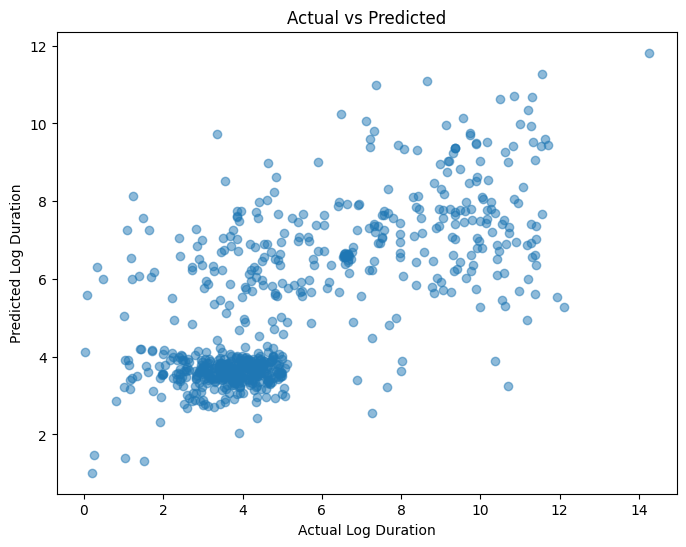

In [2648]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, preds, alpha=0.5)

plt.xlabel("Actual Log Duration")
plt.ylabel("Predicted Log Duration")
plt.title("Actual vs Predicted")

plt.show()

## Extract Trained Random Forest Model

The Random Forest model has been trained and evaluated. Now save the trained model artifact so it can be reused outside this notebook.

In [2649]:
import joblib
import json

model_artifact_path = "traffic_duration_random_forest_model.pkl"
feature_columns_path = "traffic_duration_feature_columns.json"

joblib.dump(model, model_artifact_path)

feature_columns = list(X_train.columns)

with open(feature_columns_path, "w") as f:
    json.dump(feature_columns, f)

model_artifact_path, feature_columns_path

('traffic_duration_random_forest_model.pkl',
 'traffic_duration_feature_columns.json')

### Validate Saved Model

Load the saved artifact and confirm it gives predictions on the same test features.

In [2650]:
loaded_model = joblib.load(model_artifact_path)

loaded_preds = loaded_model.predict(X_test.head(5))

loaded_preds

array([4.57686157, 3.40673831, 7.66796102, 9.39827133, 3.55666283])

In [2651]:
model_df["duration_minutes"].quantile(
    [0.25, 0.50, 0.75, 0.90]
)

0.25       29.325840
0.50       72.344167
0.75      792.710842
0.90    17145.956512
Name: duration_minutes, dtype: float64

In [2652]:
pd.cut(
    model_df["duration_minutes"],
    bins=[
        -1,
        model_df["duration_minutes"].quantile(0.50),
        model_df["duration_minutes"].quantile(0.75),
        model_df["duration_minutes"].quantile(0.90),
        model_df["duration_minutes"].max()
    ]
).value_counts()

duration_minutes
(-1.0, 72.344]              1796
(72.344, 792.711]            898
(792.711, 17145.957]         538
(17145.957, 2051059.221]     360
Name: count, dtype: int64

In [2653]:
def impact_level(x):
    if x <= 72:
        return "Low"
    elif x <= 793:
        return "Medium"
    elif x <= 17146:
        return "High"
    else:
        return "Critical"

In [2654]:
model_df["impact_level"] = model_df["duration_minutes"].apply(
    impact_level
)

In [2655]:
model_df["impact_level"].value_counts()

impact_level
Low         1791
Medium       903
High         538
Critical     360
Name: count, dtype: int64

In [2656]:
X = model_df.drop(
    columns=[
        "duration_minutes",
        "log_duration",
        "impact_level"
    ]
)

y = model_df["impact_level"]

In [2657]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [2658]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ("preprocessor", preprocessor),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [2659]:
clf.fit(
    X_train,
    y_train
)

C:\Users\bhard\AppData\Roaming\Python\Python312\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['event_cause_grouped',
                                                   'event_type', 'priority',
                                                   'corridor', 'zone'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [2660]:
preds = clf.predict(X_test)

In [2661]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, preds)
)

print(
    classification_report(
        y_test,
        preds
    )
)

Accuracy: 0.5924895688456189
              precision    recall  f1-score   support

    Critical       0.42      0.44      0.43        72
        High       0.44      0.50      0.47       108
         Low       0.70      0.84      0.77       358
      Medium       0.43      0.21      0.28       181

    accuracy                           0.59       719
   macro avg       0.50      0.50      0.49       719
weighted avg       0.57      0.59      0.57       719



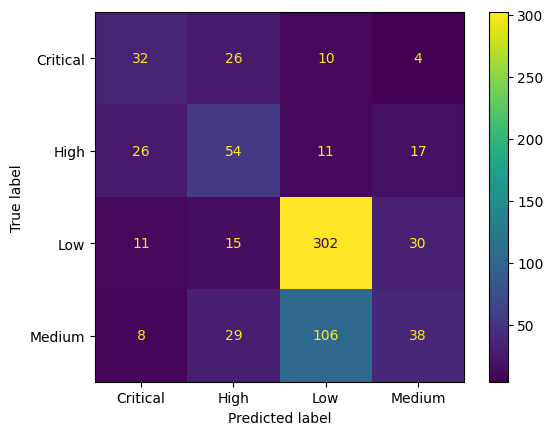

In [2662]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds
)

In [2663]:
accuracy_score(y_test, preds)

0.5924895688456189

## Extract Trained Random Forest Classifier

The Random Forest classifier has been trained and evaluated. Save the full classifier pipeline so preprocessing and classification can be reused outside this notebook.

In [2664]:
import joblib
import json

classifier_artifact_path = "traffic_impact_random_forest_classifier.pkl"
classifier_feature_columns_path = "traffic_impact_classifier_feature_columns.json"

joblib.dump(clf, classifier_artifact_path)

classifier_feature_columns = list(X_train.columns)

with open(classifier_feature_columns_path, "w") as f:
    json.dump(classifier_feature_columns, f)

classifier_artifact_path, classifier_feature_columns_path

('traffic_impact_random_forest_classifier.pkl',
 'traffic_impact_classifier_feature_columns.json')

### Validate Saved Classifier

Load the saved classifier artifact and confirm it predicts on the same test features.

In [2665]:
loaded_classifier = joblib.load(classifier_artifact_path)

loaded_classifier_preds = loaded_classifier.predict(X_test.head(10))

loaded_classifier_preds

array(['High', 'Critical', 'Low', 'Low', 'Low', 'Low', 'Critical', 'Low',
       'Low', 'Low'], dtype=object)

In [2666]:
import xgboost
print(xgboost.__version__)

3.2.0


In [2667]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

In [2668]:
X = model_df.drop(
    columns=["duration_minutes", "log_duration"]
)


y = model_df["log_duration"]

In [2669]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [2670]:
categorical_cols = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone"
]

numeric_cols = [
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month"
]

In [2671]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [2672]:
X = model_df.drop(
    columns=[
        "duration_minutes",
        "log_duration",
        "impact_level"
    ]
)

In [2673]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [2674]:
xgb_model.fit(X_train, y_train
              )

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['event_cause_grouped',
                                                   'event_type', 'priority',
                                                   'requires_road_closure',
                                                   'corridor', 'zone']),
                                                 ('num', 'passthrough',
                                                  ['latitude', 'longitude',
                                                   'hour', 'day_of_week',
                                                   'month'])])),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsam...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [2675]:
xgb_preds = xgb_model.predict(X_test
                              )

In [2676]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, xgb_preds))
print("R2 :", r2_score(y_test, xgb_preds))

MAE: 1.4069264360758582
R2 : 0.4659546546313925


In [2677]:
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)

model_df["rush_hour"] = model_df["hour"].isin(
    [7, 8, 9, 17, 18, 19, 20]
).astype(int)

In [2678]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

model_df["location_cluster"] = kmeans.fit_predict(
    model_df[["latitude", "longitude"]]
)

In [2679]:
model_df["is_weekend"].value_counts()

is_weekend
0    2650
1     942
Name: count, dtype: int64

In [2680]:
categorical_cols = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone",
    "location_cluster"
]

numeric_cols = [
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "rush_hour"
]

In [2681]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [2682]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [2683]:
RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [2684]:
X = model_df.drop(
    columns=[
        "duration_minutes",
        "log_duration"
    ]
)

y = model_df["log_duration"]

In [2685]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [2686]:
X_train.shape

(2873, 15)

In [2687]:
X_train.columns

Index(['event_cause_grouped', 'event_type', 'priority',
       'requires_road_closure', 'corridor', 'zone', 'latitude', 'longitude',
       'hour', 'day_of_week', 'month', 'impact_level', 'is_weekend',
       'rush_hour', 'location_cluster'],
      dtype='object')

In [2688]:
X = model_df.drop(
    columns=[
        "duration_minutes",
        "log_duration",
        "impact_level"
    ]
)

In [2689]:
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2 :", r2_score(y_test, preds))

MAE: 1.3913761812081578
R2 : 0.4745293007073379


In [2690]:
df["description"].value_counts()    

description
Starting problem                                                                                                        80
starting problem                                                                                                        58
[PERSON]                                                                                                                42
Vehicle breakdown                                                                                                       29
Vehicle break down                                                                                                      28
                                                                                                                        ..
LCV is off road due starting problem [PERSON] to [LOCATION] right side of the road traffic is moving little bit slow     1
Bmtc bus off at vasantapura cross signal incoming side sir                                                               1
Bmtc

In [2691]:
df["description"].isna().sum()

np.int64(1360)

In [2692]:
df_completed["description"] = (
    df_completed["description"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

In [2693]:
df_completed["description"] = (
    df_completed["description"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

In [2694]:
import numpy as np

df_completed["log_duration"] = np.log1p(
    df_completed["duration_minutes"]
)

C:\Users\bhard\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [2695]:
model_features = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone",
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month",
    "description"
]

target = ["duration_minutes", "log_duration"]

model_df = df_completed[
    model_features + target
].copy()

In [2696]:
model_df["description"].sample(
    20,
    random_state=42
).tolist()

['tata tolto vehicle, clutch rod cut aagide. traffic moment slow ide sir..',
 '',
 'bmtc bus off at vasantapura cross signal incoming side sir',
 'vahicle gear box problem',
 'break failure at kg road near pothys',
 'innova private car off road due to starting problem near hmt bhavana (incoming side )  traffic no problem sir',
 'mes road towards gg palya bbmp vehicle',
 'vehicle breakdown',
 'battery problem',
 'gear shifting problem',
 'test demo',
 '[location] side sir',
 'vehicle front tyre blast',
 '',
 'towards mysore',
 'starter problem',
 'ನಮಸ್ತೆ ಸರ್ ನಾಗವಾರ ಅಕ್ಬರ್ ರಾಮ್ ಟುವರ್ಡ್ ಕೆಇಬಿ ಕಡೆ ಸ್ಲೋ ಮೊಮೆಂಟ್ ಇರುತ್ತದೆ ಸರ್',
 '[person]',
 'bmtc of road, [location] towards old udaya tv',
 'hqtc bus stop [person] ನಗರ ಕ್ರಾಸ್ ಕಡೆ ಹೋಗುವ ಈ ವಾಹನವು ಕೆಟ್ಟು ನಿಂತಿರುತ್ತದೆ ಸರ್ ಸಂಚಾರಕ್ಕೆ ಯಾವುದೇ ತೊಂದರೆ ಇರುವುದಿಲ್ಲ']

In [2697]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [2698]:
categorical_cols = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone"
]

numeric_cols = [
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month"
]

text_col = "description"

In [2699]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
        ("text", TfidfVectorizer(max_features=200), text_col)
    ]
)

In [2700]:
X = model_df.drop(columns=["duration_minutes", "log_duration"])
y = model_df["log_duration"]

In [2701]:
model_tfidf = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [2702]:
model_df = model_df[model_df["duration_minutes"] >= 0].copy()

import numpy as np
model_df["log_duration"] = np.log1p(model_df["duration_minutes"])

In [2703]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2704]:
X = model_df.drop(columns=["duration_minutes", "log_duration"])
y = model_df["log_duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2705]:
model_tfidf.fit(X_train, y_train)

preds = model_tfidf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2 :", r2_score(y_test, preds))

MAE: 1.396025991849962
R2 : 0.47218955790964623


In [2706]:
p99 = model_df["duration_minutes"].quantile(0.99)

model_df_trim = model_df[
    model_df["duration_minutes"] <= p99
].copy()

In [2707]:
for k in [5, 10, 15, 20]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    model_df[f"location_cluster_{k}"] = kmeans.fit_predict(
        model_df[["latitude", "longitude"]]
    )

In [2708]:
X = model_df.drop(
    columns=[
        "duration_minutes",
        "log_duration"
    ]
)

In [2709]:
categorical_cols = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone",
    "location_cluster_5"
]

In [2710]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Remove extreme outliers above P99
p99 = model_df["duration_minutes"].quantile(0.99)

model_df_trim = model_df[
    model_df["duration_minutes"] <= p99
].copy()

# 2. Recreate log target
model_df_trim["log_duration"] = np.log1p(
    model_df_trim["duration_minutes"]
)

# 3. Create location cluster
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

model_df_trim["location_cluster_5"] = kmeans.fit_predict(
    model_df_trim[["latitude", "longitude"]]
)

# 4. X and y
X = model_df_trim.drop(
    columns=[
        "duration_minutes",
        "log_duration"
    ]
)

y = model_df_trim["log_duration"]

# 5. Column groups
categorical_cols = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone",
    "location_cluster_5"
]

numeric_cols = [
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month"
]

# 6. Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# 7. Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8. Model
model_trim_cluster = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# 9. Train + evaluate
model_trim_cluster.fit(X_train, y_train)

preds = model_trim_cluster.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2 :", r2_score(y_test, preds))

MAE: 1.3011861323167748
R2 : 0.4669503450563175


In [2711]:
df["veh_type"].value_counts(dropna=False)

veh_type
NaN              3286
bmtc_bus         1466
heavy_vehicle     965
lcv               678
others            449
private_bus       359
private_car       345
truck             276
ksrtc_bus         217
taxi               95
auto               37
Name: count, dtype: int64

In [2712]:
model_df["veh_type"] = (
    df["veh_type"]
    .fillna("Unknown")
)

In [2713]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --------------------------
# Features
# --------------------------

X = model_df.drop(
    columns=[
        "duration_minutes",
        "log_duration"
    ]
)

y = model_df["log_duration"]

# --------------------------
# Column groups
# --------------------------

categorical_cols = [
    "event_cause_grouped",
    "event_type",
    "priority",
    "requires_road_closure",
    "corridor",
    "zone",
    "veh_type"
]

numeric_cols = [
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "month"
]

# --------------------------
# Preprocessor
# --------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numeric_cols
        )
    ]
)

# --------------------------
# Train/Test Split
# --------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------
# Model
# --------------------------

model_veh = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# --------------------------
# Train
# --------------------------

model_veh.fit(
    X_train,
    y_train
)

# --------------------------
# Predict
# --------------------------

preds = model_veh.predict(
    X_test
)

# --------------------------
# Metrics
# --------------------------

print(
    "MAE:",
    mean_absolute_error(y_test, preds)
)

print(
    "R2:",
    r2_score(y_test, preds)
)

MAE: 1.3816872764226396
R2: 0.476868903279148
